In [1]:
import pandas as pd
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer
from gensim import corpora, models


In [11]:
# Assuming the CSV file has a column named 'dialogue' containing the dialogues
df = pd.read_csv('kanan.csv')


In [12]:
df

,Subtitle
0,Good evening.
1,Hello. How are you?
2,It's great to be back in India. I've been
3,"traveling the world a lot this year,"
4,"so it's good to be back in Bangalore,"
...,...
1645,[cheering and applause]
1646,Thank you.
1647,That's the show.
1648,[closing music playing]


In [21]:
# Assuming the dialogues are in the first column (index 0)
dialogues = df.iloc[:, 0]

In [22]:
# Preprocess the text
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/alisha/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /Users/alisha/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/alisha/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [13]:
df

,Subtitle
0,Good evening.
1,Hello. How are you?
2,It's great to be back in India. I've been
3,"traveling the world a lot this year,"
4,"so it's good to be back in Bangalore,"
...,...
1645,[cheering and applause]
1646,Thank you.
1647,That's the show.
1648,[closing music playing]


In [21]:
# Load the regular expression library
import re
# Remove punctuation
df['paper_text_processed'] = \
df['Subtitle'].map(lambda x: re.sub('[,\.!?]', '', x))
# Convert the titles to lowercase
df['paper_text_processed'] = \
df['paper_text_processed'].map(lambda x: x.lower())
# Print out the first rows of papers
df['paper_text_processed']

0                                   good evening
1                              hello how are you
2       it's great to be back in india i've been
3            traveling the world a lot this year
4           so it's good to be back in bangalore
                          ...                   
1645                     [cheering and applause]
1646                                   thank you
1647                             that's the show
1648                     [closing music playing]
1649                                [music ends]
Name: paper_text_processed, Length: 1650, dtype: object

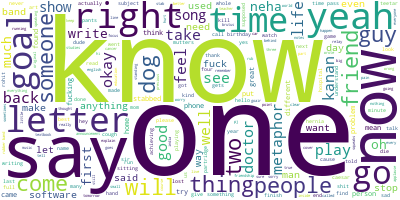

In [22]:
# Import the wordcloud library
from wordcloud import WordCloud
# Join the different processed titles together.
long_string = ','.join(list(df['paper_text_processed'].values))
# Create a WordCloud object
wordcloud = WordCloud(background_color="white", max_words=700, contour_width=3, contour_color='steelblue')
# Generate a word cloud
wordcloud.generate(long_string)
# Visualize the word cloud
wordcloud.to_image()

In [76]:
import gensim
from gensim.utils import simple_preprocess
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = stopwords.words('english')
stop_words.extend(['from', 'subject', 're', 'edu', 'use', 'one', 'say', 'yeah', 'know', 'says', 'said', 'come', 'came', 'like', 'would', 'need', 'go'])
def sent_to_words(sentences):
    for sentence in sentences:
        # deacc=True removes punctuations
        yield(gensim.utils.simple_preprocess(str(sentence), deacc=True))
def remove_stopwords(texts):
    return [[word for word in simple_preprocess(str(doc)) 
             if word not in stop_words] for doc in texts]
data = df.paper_text_processed.values.tolist()
data_words = list(sent_to_words(data))
# remove stop words
data_words = remove_stopwords(data_words)
print(data_words[:1][0][:30])

['good', 'evening']


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/alisha/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


/Users/alisha/anaconda3/lib/python3.10/site-packages/wordcloud/wordcloud.py:106: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  self.colormap = plt.cm.get_cmap(colormap)


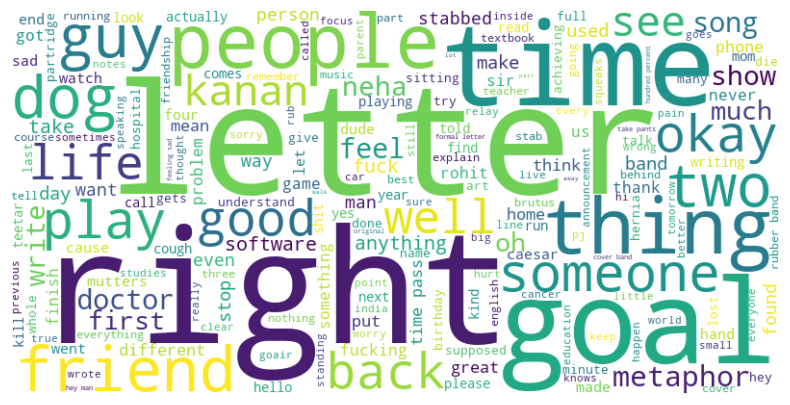

In [77]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Convert list of lists to a single string
long_string = ' '.join([' '.join(words) for words in data_words])

# Generate a word cloud
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(long_string)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.show()

In [78]:
import gensim
from gensim.utils import simple_preprocess
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
stop_words = stopwords.words('english')
stop_words.extend(['from', 'subject', 're', 'edu', 'use'])
def sent_to_words(sentences):
    for sentence in sentences:
        # deacc=True removes punctuations
        yield(gensim.utils.simple_preprocess(str(sentence), deacc=True))
def remove_stopwords(texts):
    return [[word for word in simple_preprocess(str(doc)) 
             if word not in stop_words] for doc in texts]
# data = data_words.values.tolist()
# data_words = list(sent_to_words(data))
# remove stop words
data_words = remove_stopwords(data_words)
print(data_words[:1][0][:30])

['good', 'evening']


[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/alisha/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [79]:
import gensim.corpora as corpora
# Create Dictionary
id2word = corpora.Dictionary(data_words)
# Create Corpus
texts = data_words
# Term Document Frequency
corpus = [id2word.doc2bow(text) for text in texts]
# View
print(corpus[:1][0][:30])

[(0, 1), (1, 1)]


In [80]:
from pprint import pprint
# number of topics
num_topics = 10
# Build LDA model
lda_model = gensim.models.LdaMulticore(corpus=corpus,
                                       id2word=id2word,
                                       num_topics=num_topics)
# Print the Keyword in the 10 topics
pprint(lda_model.print_topics())
doc_lda = lda_model[corpus]

[(0,
  '0.022*"kanan" + 0.020*"used" + 0.017*"yes" + 0.015*"friend" + 0.015*"oh" + '
  '0.012*"dog" + 0.010*"studies" + 0.008*"get" + 0.008*"man" + 0.008*"stop"'),
 (1,
  '0.013*"much" + 0.011*"watch" + 0.011*"stabbed" + 0.011*"okay" + '
  '0.011*"back" + 0.009*"get" + 0.009*"dog" + 0.009*"anything" + 0.009*"make" '
  '+ 0.009*"show"'),
 (2,
  '0.026*"time" + 0.015*"people" + 0.013*"take" + 0.013*"home" + 0.011*"pass" '
  '+ 0.009*"band" + 0.009*"fight" + 0.009*"fun" + 0.009*"game" + 0.009*"sad"'),
 (3,
  '0.025*"someone" + 0.014*"write" + 0.013*"two" + 0.011*"phone" + '
  '0.011*"right" + 0.011*"song" + 0.011*"back" + 0.011*"see" + 0.011*"show" + '
  '0.008*"speaking"'),
 (4,
  '0.017*"goals" + 0.017*"let" + 0.012*"band" + 0.012*"right" + 0.012*"day" + '
  '0.008*"ha" + 0.008*"good" + 0.008*"try" + 0.008*"art" + 0.008*"want"'),
 (5,
  '0.019*"metaphor" + 0.015*"get" + 0.015*"letter" + 0.013*"life" + '
  '0.013*"thing" + 0.011*"problem" + 0.009*"full" + 0.009*"people" + '
  '0.009*"tim


Coherence Score: 0.7150562515730741


/Users/alisha/anaconda3/lib/python3.10/site-packages/wordcloud/wordcloud.py:106: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  self.colormap = plt.cm.get_cmap(colormap)
/Users/alisha/anaconda3/lib/python3.10/site-packages/wordcloud/wordcloud.py:106: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  self.colormap = plt.cm.get_cmap(colormap)
/Users/alisha/anaconda3/lib/python3.10/site-packages/wordcloud/wordcloud.py:106: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  self.colormap = 

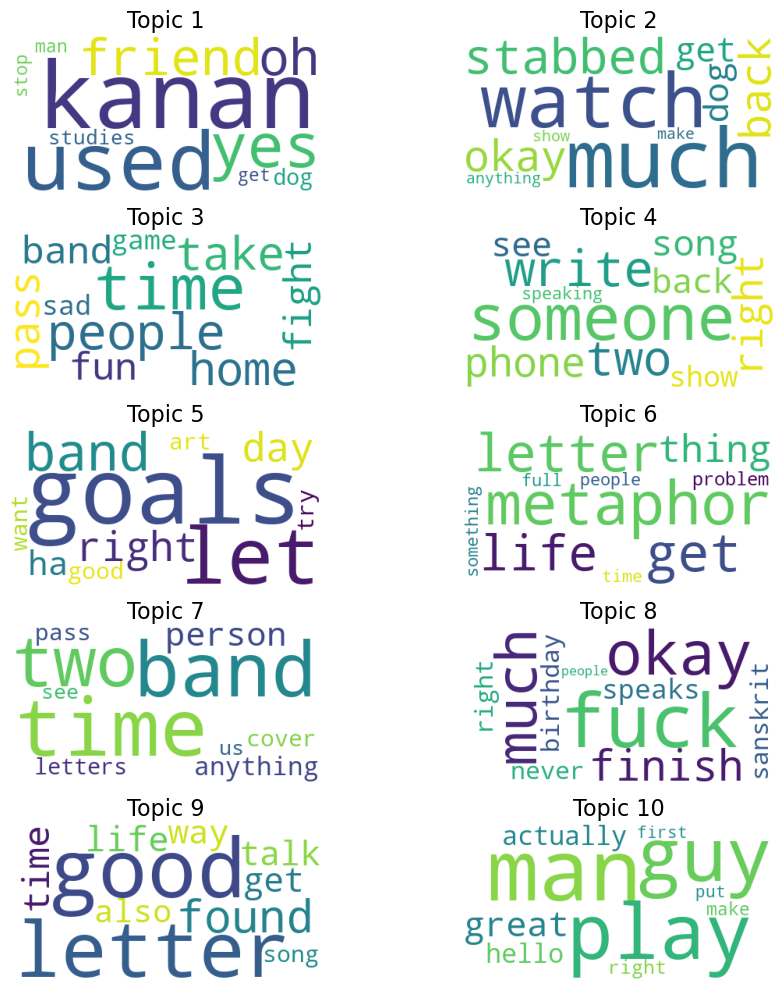

In [81]:
import matplotlib.pyplot as plt
from gensim.models import CoherenceModel

# Compute coherence score
coherence_model_lda = CoherenceModel(model=lda_model, texts=data_words, dictionary=id2word, coherence='c_v')
coherence_lda = coherence_model_lda.get_coherence()
print('\nCoherence Score:', coherence_lda)

# Visualize topics
topics = lda_model.show_topics(formatted=False)

# Plotting
fig, axes = plt.subplots(num_topics // 2, 2, figsize=(10,10), sharex=True, sharey=True)

for i, ax in enumerate(axes.flatten()):
    fig.add_subplot(ax)
    topic_words = dict(topics[i][1])
    cloud = WordCloud(background_color='white').generate_from_frequencies(topic_words)
    plt.gca().imshow(cloud)
    plt.gca().set_title('Topic ' + str(i+1), fontdict=dict(size=16))
    plt.gca().axis('off')

plt.subplots_adjust(wspace=0, hspace=0)
plt.axis('off')
plt.margins(x=0, y=0)
plt.tight_layout()
plt.show()


In [82]:
import pyLDAvis
import pyLDAvis.gensim
import pickle 
import os

# Visualize the topics
pyLDAvis.enable_notebook()
LDAvis_data_filepath = os.path.join('./results/ldavis_prepared_'+str(num_topics))
# # this is a bit time consuming - make the if statement True
# # if you want to execute visualization prep yourself
if 1 == 1:
    LDAvis_prepared = pyLDAvis.gensim.prepare(lda_model, corpus, id2word)
    with open(LDAvis_data_filepath, 'wb') as f:
        pickle.dump(LDAvis_prepared, f)
# load the pre-prepared pyLDAvis data from disk
with open(LDAvis_data_filepath, 'rb') as f:
    LDAvis_prepared = pickle.load(f)
pyLDAvis.save_html(LDAvis_prepared, './results/ldavis_prepared_'+ str(num_topics) +'.html')
LDAvis_prepared

BrokenProcessPool: A task has failed to un-serialize. Please ensure that the arguments of the function are all picklable.